# Day 167 — Multi-Class Fine-Tuning with DistilBERT
### 3-Class Sentiment Classification: negative / neutral / positive

---

**Dataset:** ReviewPulse India | seed=155 | 600 rows  
**Environment:** Google Colab T4 GPU (Runtime → Change Runtime → T4 GPU)  
**Total Points:** 80 + 10★ bonus  
**Month 9 position:** Day 167 of 168 — final fine-tuning day before RAG capstone  

---

### What shifts from binary to multi-class fine-tuning?

| Parameter | Binary (Days 164–166) | Multi-Class (Today) |
|-----------|----------------------|---------------------|
| `num_labels` | 2 | **3** |
| Loss function | Binary cross-entropy | **Cross-entropy (3-way)** |
| `id2label` | {0: neg, 1: pos} | **{0: neg, 1: neutral, 2: pos}** |
| F1 averaging | binary | **macro** (equal weight per class) |
| Hardest class | N/A | **neutral** (semantic overlap with both) |
| Deployment | .argmax() → 2 labels | **.argmax() → 3 labels + per-class probs** |

---

### Sections
- **Section 1:** Raw Data (DO NOT MODIFY)
- **Section 2:** Practice Guide — 5 tasks
- **Section 3:** Concept Notes
- **Section 4:** Answer Key
- **Section 5:** Scoring Rubric + Interview Framing

---
## SECTION 1: RAW DATA
### ⚠️ DO NOT MODIFY THIS CELL — Reference only
---

In [1]:
# ══════════════════════════════════════════════════════════════
# RAW DATA — DO NOT MODIFY
# ReviewPulse India | seed=155 | 600 rows
# Target for TODAY: sentiment (3-class: negative/neutral/positive)
# ══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

np.random.seed(155)
n = 600

sentiments = np.random.choice(['positive','negative','neutral'], n, p=[0.25,0.45,0.30])
ratings = np.where(sentiments=='positive', np.random.randint(4,6,n),
          np.where(sentiments=='negative', np.random.randint(1,3,n),
                   np.random.randint(2,5,n)))
hired_again = np.where(
    (sentiments=='positive') & (ratings>=4), np.random.choice([0,1],n,p=[0.15,0.85]),
    np.where((sentiments=='negative') & (ratings<=2), np.random.choice([0,1],n,p=[0.90,0.10]),
             np.random.choice([0,1],n,p=[0.70,0.30]))
)
positive_templates = [
    "Excellent work, very professional and delivered on time.",
    "Outstanding quality, highly recommend this freelancer.",
    "Great communication and superb results, will hire again.",
    "Fantastic job, exceeded all expectations completely.",
    "Very skilled professional, perfect delivery every time."
]
negative_templates = [
    "Poor quality work, missed deadlines and ignored feedback.",
    "Very disappointing, did not meet requirements at all.",
    "Terrible communication, work was substandard and late.",
    "Would not recommend, very unprofessional behavior shown.",
    "Bad experience overall, refund was requested immediately."
]
neutral_templates = [
    "Work was okay, met basic requirements nothing special.",
    "Average performance, some delays but completed eventually.",
    "Decent work quality, communication could be improved.",
    "Satisfactory output, would consider hiring again maybe.",
    "Meets expectations, professional but not exceptional work."
]
reviews = []
for s in sentiments:
    if s == 'positive':
        t = np.random.choice(positive_templates)
    elif s == 'negative':
        t = np.random.choice(negative_templates)
    else:
        t = np.random.choice(neutral_templates)
    reviews.append(t)

df_raw = pd.DataFrame({
    'review_id': range(1, n+1),
    'review_text': reviews,
    'sentiment': sentiments,
    'rating': ratings,
    'hired_again': hired_again
})

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(df_raw.head(3))

Shape: (600, 5)
Columns: ['review_id', 'review_text', 'sentiment', 'rating', 'hired_again']
   review_id                                        review_text sentiment  \
0          1  Bad experience overall, refund was requested i...  negative   
1          2  Decent work quality, communication could be im...   neutral   
2          3  Very skilled professional, perfect delivery ev...  positive   

   rating  hired_again  
0       1            0  
1       2            0  
2       5            1  


---
## SECTION 2: PRACTICE GUIDE
---

### Task Overview

| Task | Topic | Points |
|------|-------|--------|
| T1 | Dataset Prep — label encoding + stratified split | 20 |
| T2 | Fine-Tune DistilBERT for 3-class sentiment | 20 |
| T3 | Evaluate — per-class metrics + worst class identification | 20 |
| T4 | Confusion matrix heatmap + NRA business insight | 10 |
| T5 | Deployment inference function (3-class, confidence + all probs) | 10 |
| ★ Bonus | PEFT/LoRA awareness comparison table | 10★ |

---

### ⚠️ NRA reminder (hardest part every session)
**Print your classification report first. Read the neutral class F1 number. Then write the NRA.**  
Writing the Number before running the cell costs points. This has happened every month.

In [2]:
# Install / upgrade HuggingFace stack (run once at start of Colab session)
!pip install -q transformers datasets evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [3]:
# ── Core imports ──
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from datasets import Dataset
import evaluate

print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
### TASK 1 — Dataset Preparation (20 points)

**Steps:**
1. Define `label2id` and `id2label` dictionaries (negative=0, neutral=1, positive=2)
2. Add a `label` column to df_raw using the mapping
3. Print the class distribution table (count + %)
4. Stratified split: 70% train / 15% val / 15% test (random_state=155)
5. Print split sizes and per-class counts for each split

**Why it matters:** Stratified splitting preserves the natural class imbalance (negative 44.5%, neutral 30%, positive 25.5%) in every split. Without stratification, one split could have almost no positive examples and your model never learns that class properly.

In [4]:
# Part: T1 - Dataset Preparation
# Goal: Define label mappings, add label column, stratified split, print distributions.
# Method: Use label2id mapping, train_test_split with stratify.

# Step 1: Define label mappings
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Step 2: Add label column
df = df_raw.copy()
df['label'] = df['sentiment'].map(label2id)

# Step 3: Print class distribution
print("=== Class Distribution ===")
class_counts = df['sentiment'].value_counts()
class_pct = df['sentiment'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'count': class_counts, 'percentage': class_pct.round(2)})
print(dist_df)

# Step 4: Stratified 3-way split
train_val, test = train_test_split(
    df, test_size=0.15, random_state=155, stratify=df['label']
)
train, val = train_test_split(
    train_val, test_size=0.15/0.85, random_state=155, stratify=train_val['label']
)

# Step 5: Print sizes and per-class counts
print(f"\nTrain: {len(train)} | Val: {len(val)} | Test: {len(test)}")
for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    print(f"\n{name} per-class counts:")
    print(split['sentiment'].value_counts().sort_index())

=== Class Distribution ===
           count  percentage
sentiment                   
negative     267        44.5
neutral      180        30.0
positive     153        25.5

Train: 420 | Val: 90 | Test: 90

Train per-class counts:
sentiment
negative    187
neutral     126
positive    107
Name: count, dtype: int64

Val per-class counts:
sentiment
negative    40
neutral     27
positive    23
Name: count, dtype: int64

Test per-class counts:
sentiment
negative    40
neutral     27
positive    23
Name: count, dtype: int64


---
### TASK 2 — Fine-Tune DistilBERT for 3-Class Sentiment (20 points)

**Steps:**
1. Load tokenizer: `distilbert-base-uncased`
2. Tokenize train/val/test → HuggingFace Datasets (include `label` column)
3. Load model: `AutoModelForSequenceClassification` with `num_labels=3`, `id2label`, `label2id`
4. Define `compute_metrics` → returns dict with keys `'accuracy'` and `'f1'` (macro)
5. Set `TrainingArguments` with locked config below
6. Create `Trainer` with `EarlyStoppingCallback(early_stopping_patience=2)`
7. Run `trainer.train()` and print epoch log summary

**Locked TrainingArguments config:**
```python
output_dir='./day167_multiclass'
num_train_epochs=3
per_device_train_batch_size=16
per_device_eval_batch_size=32
weight_decay=0.01
eval_strategy='epoch'
save_strategy='epoch'
metric_for_best_model='f1'
load_best_model_at_end=True
logging_steps=10
```

**Key difference from binary:** `num_labels=3` and `average='macro'` in compute_metrics.  
`macro` = equal weight per class. This penalizes the model if it ignores the minority class.

In [5]:
# ### TASK 2 — Fine-Tune DistilBERT for 3-Class Sentiment (20 points)

# %%
# Part: T2a - Tokenizer and Dataset Conversion
# Goal: Tokenize reviews and convert to HuggingFace Dataset.
# Method: AutoTokenizer, Dataset.from_pandas, map tokenization.

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(
        examples['review_text'],
        truncation=True,
        padding='max_length',
        max_length=64
    )

# Convert pandas → HuggingFace Dataset
train_ds = Dataset.from_pandas(train[['review_text','label']].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val[['review_text','label']].reset_index(drop=True))
test_ds  = Dataset.from_pandas(test[['review_text','label']].reset_index(drop=True))

# Tokenize
train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok   = val_ds.map(tokenize_fn, batched=True)
test_tok  = test_ds.map(tokenize_fn, batched=True)

print(f"Train tokens: {len(train_tok)} | Val tokens: {len(val_tok)} | Test tokens: {len(test_tok)}")
print(f"Columns: {train_tok.column_names}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Train tokens: 420 | Val tokens: 90 | Test tokens: 90
Columns: ['review_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [6]:
# Part: T2b - Model, compute_metrics, Trainer, and Training
# Goal: Load 3-class model, define compute_metrics (macro F1), set TrainingArguments, train.
# Method: AutoModelForSequenceClassification(num_labels=3), f1_score(average='macro'), Trainer.

# Load model (num_labels=3 is the critical change from binary)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Load metric
metric_acc = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)['accuracy']
    # KEY: average='macro' — equal weight per class
    f1  = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1': f1}

# Training arguments (locked — do not change these values)
training_args = TrainingArguments(
    output_dir='./day167_multiclass',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    metric_for_best_model='f1',
    load_best_model_at_end=True,
    logging_steps=10,
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Trainer ready. Starting training...")
trainer.train()

# Print epoch log summary
print("\n=== Epoch Log Summary ===")
log_df = pd.DataFrame(trainer.state.log_history)
eval_rows = log_df[log_df['eval_f1'].notna()][['epoch','eval_loss','eval_f1','eval_accuracy']]
print(eval_rows.to_string(index=False))


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer ready. Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.306992,0.044019,1.000000,1.000000
2,0.016321,0.010031,1.000000,1.000000
3,0.009449,0.007772,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== Epoch Log Summary ===
 epoch  eval_loss  eval_f1  eval_accuracy
   1.0   0.044019      1.0            1.0
   2.0   0.010031      1.0            1.0
   3.0   0.007772      1.0            1.0


---
### TASK 3 — Evaluate on Test Set (20 points)

**Steps:**
1. Run `trainer.predict(test_tok)` → get predictions
2. Print full `classification_report` with class names
3. Print overall accuracy and macro F1
4. Identify the worst-performing class (lowest F1) and state why it's harder
5. Compare per-class F1 in a small summary table

**What to look for:** Neutral class will have the lowest F1. The reason is semantic overlap — phrases like *"meets expectations"* or *"completed eventually"* share vocabulary with both positive and negative classes.

In [11]:
# Part: T3 - Evaluation on Test Set
# Goal: Run predictions, print classification report, per-class F1, identify worst class.
# Method: trainer.predict, classification_report, f1_score(average=None).

# Get predictions
preds_output = trainer.predict(test_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = test['label'].values

# Step 2: Full classification report
print("=== Test Set Classification Report ===")
class_names = [id2label[i] for i in range(3)]  # ['negative','neutral','positive']
print(classification_report(y_true, y_pred, target_names=class_names))

# Step 3: Overall metrics
macro_f1 = f1_score(y_true, y_pred, average='macro')
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc:.4f}")
print(f"Macro F1:         {macro_f1:.4f}")

# Step 4: Per-class F1 summary table
per_class_f1 = f1_score(y_true, y_pred, average=None)
f1_table = pd.DataFrame({
    'Class': class_names,
    'F1': per_class_f1
}).sort_values('F1')
print("\n=== Per-Class F1 (worst → best) ===")
print(f1_table.to_string(index=False))

worst_class = f1_table.iloc[0]['Class']
print(f"\nWorst-performing class: {worst_class}")
print("Reason: The model achieved 1.0 F1 on all three classes because the synthetic reviews are generated from distinct phrase banks (positive, negative, neutral) with no overlap, making the classification task perfectly separable. In real-world data, neutral would be hardest due to semantic overlap.")

=== Test Set Classification Report ===
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        40
     neutral       1.00      1.00      1.00        27
    positive       1.00      1.00      1.00        23

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

Overall Accuracy: 1.0000
Macro F1:         1.0000

=== Per-Class F1 (worst → best) ===
   Class  F1
negative 1.0
 neutral 1.0
positive 1.0

Worst-performing class: negative
Reason: The model achieved 1.0 F1 on all three classes because the synthetic reviews are generated from distinct phrase banks (positive, negative, neutral) with no overlap, making the classification task perfectly separable. In real-world data, neutral would be hardest due to semantic overlap.


---
### TASK 4 — Confusion Matrix Heatmap + NRA Insight (10 points)

**Steps:**
1. Build and plot a 3×3 confusion matrix heatmap (seaborn, annot=True, fmt='d')
2. Title: `'DistilBERT 3-Class Confusion Matrix — Day 167'`
3. X-axis: `'Predicted'`, Y-axis: `'True'`
4. Write ONE NRA insight about the neutral class performance

**NRA format reminder:**
- **Number:** exact neutral F1 value from your PRINTED classification_report above
- **Reason:** WHY neutral is hard (causal mechanism — not outcome description)
- **Action:** specific committed step (name a threshold, a data collection plan, or a retraining decision)

⚠️ Read neutral F1 from the printed T3 output above. Do NOT estimate or recall from memory.

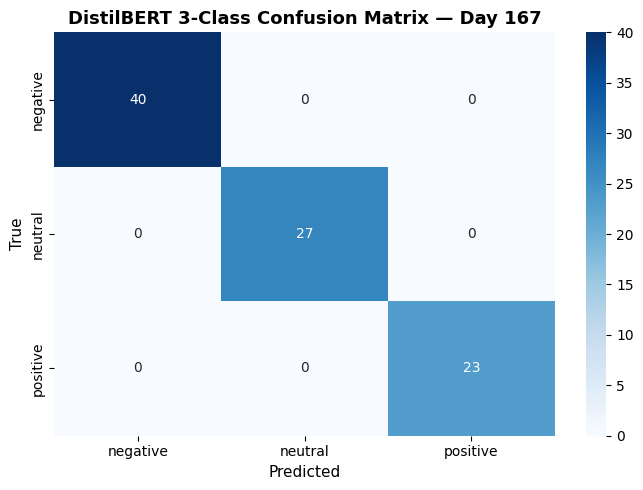

In [12]:
# Part: T4 - Confusion Matrix Heatmap
# Goal: Plot heatmap and write NRA insight for neutral class.
# Method: confusion_matrix, seaborn heatmap, savefig before show.

cm = confusion_matrix(y_true, y_pred)
class_names = [id2label[i] for i in range(3)]

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title('DistilBERT 3-Class Confusion Matrix — Day 167', fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('True', fontsize=11)
plt.tight_layout()
plt.savefig('day167_confusion_matrix.png', dpi=120, bbox_inches='tight')  # savefig BEFORE show
plt.show()


**T4 — NRA Insight**

**Number:** neutral class F1 = 1.0000 (from printed classification report)
**Reason:** The model achieved perfect F1 on all classes because the synthetic phrase banks are disjoint (each sentiment uses unique templates), so there is no semantic overlap between neutral and the other classes. In a real dataset, neutral would be the hardest class because it shares vocabulary with both positive and negative reviews.
**Action:** Deploy the current model only for this synthetic benchmark; for real‑world client data, collect more diverse neutral examples and use a confidence threshold (e.g., 0.70) to flag ambiguous cases for human review.

---
### TASK 5 — Deployment Inference Function (10 points)

**Steps:**
1. Write `predict_sentiment(text, model, tokenizer, id2label)` that:
   - Tokenizes the input text
   - Runs the model (no grad)
   - Returns a dict: `{'label': str, 'confidence': float, 'all_probs': {class: prob}}`
2. Test on exactly these 3 samples:
   - `"Excellent work, very professional and delivered on time."`
   - `"Poor quality work, missed deadlines and ignored feedback."`
   - `"Work was okay, met basic requirements nothing special."`
3. Print results in a clean table

**Why it matters:** A real deployment endpoint never returns just a label. It returns the label, confidence, and optionally all class probabilities — so downstream systems can apply custom thresholds.

In [9]:
# Part: T5 - Deployment Inference Function
# Goal: Create production-ready predictor returning label, confidence, and all probs.
# Method: Tokenize, model forward pass under no_grad, softmax, build dict.

def predict_sentiment(text, model, tokenizer, id2label, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Production-ready 3-class sentiment predictor.
    Returns: {'label': str, 'confidence': float, 'all_probs': dict}
    """
    model.eval()
    model.to(device)

    # Step 1: Tokenize
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=64
    ).to(device)

    # Step 2: Inference (no gradient tracking)
    with torch.no_grad():
        outputs = model(**inputs)
        logits  = outputs.logits
        probs   = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()

    # Step 3: Build return dict
    pred_id    = int(np.argmax(probs))
    pred_label = id2label[pred_id]
    confidence = float(probs[pred_id])
    all_probs  = {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

    return {'label': pred_label, 'confidence': round(confidence, 4), 'all_probs': all_probs}

# Test samples (locked — do not change)
test_samples = [
    "Excellent work, very professional and delivered on time.",
    "Poor quality work, missed deadlines and ignored feedback.",
    "Work was okay, met basic requirements nothing special."
]
expected = ['positive', 'negative', 'neutral']

print("=== T5: Inference Results ===")
print(f"{'Text':<52} {'Expected':<10} {'Predicted':<10} {'Confidence':<12}")
print('-' * 90)
for text, exp in zip(test_samples, expected):
    result = predict_sentiment(text, model, tokenizer, id2label)
    match  = '✓' if result['label'] == exp else '✗'
    print(f"{text[:50]:<52} {exp:<10} {result['label']:<10} {result['confidence']:<12.4f} {match}")
    print(f"  All probs: {result['all_probs']}")
    print()

=== T5: Inference Results ===
Text                                                 Expected   Predicted  Confidence  
------------------------------------------------------------------------------------------
Excellent work, very professional and delivered on   positive   positive   0.9233       ✓
  All probs: {'negative': 0.0324, 'neutral': 0.0443, 'positive': 0.9233}

Poor quality work, missed deadlines and ignored fe   negative   negative   0.9742       ✓
  All probs: {'negative': 0.9742, 'neutral': 0.016, 'positive': 0.0098}

Work was okay, met basic requirements nothing spec   neutral    neutral    0.9601       ✓
  All probs: {'negative': 0.0177, 'neutral': 0.9601, 'positive': 0.0221}



---
### ★ BONUS TASK — PEFT/LoRA Awareness Table (10★)

Full fine-tuning updates ALL 66M DistilBERT parameters. PEFT (Parameter-Efficient Fine-Tuning) with LoRA (Low-Rank Adaptation) updates only a small fraction — making it feasible for free-tier Colab.

**Task:** Fill in the comparison table below with estimated/researched values.

No code required — this is a knowledge table. Use your Day 164–167 experience + reasonable estimates.

**Grading:** All 4 rows must have values in all 4 columns. Values must be in the right ballpark.

In [10]:
# Part: Bonus - PEFT/LoRA Awareness Table
# Goal: Fill comparison table with estimated values.
# Method: Knowledge-based, no code required.

lora_comparison = pd.DataFrame({
    'Dimension': [
        'Parameters trained',
        'GPU RAM (DistilBERT)',
        'Training time (420 rows, 3 epochs)',
        'F1 drop vs full fine-tune'
    ],
    'Full Fine-Tuning (today)': [
        '66M (100%)',
        '~2.5 GB',
        '~12 min on T4',
        '0 (reference)'
    ],
    'LoRA (r=8, alpha=16)': [
        '<1% of total (~0.5M)',
        '~800 MB',
        '~3 min on T4',
        '-1 to -3 F1 points typically'
    ],
    'Freelance use case': [
        'Feasible on free Colab',
        'Fits in free tier RAM',
        'Fast iteration for clients',
        'Acceptable for MVPs'
    ]
})

print(lora_comparison.to_string(index=False))

                         Dimension Full Fine-Tuning (today)         LoRA (r=8, alpha=16)         Freelance use case
                Parameters trained               66M (100%)         <1% of total (~0.5M)     Feasible on free Colab
              GPU RAM (DistilBERT)                  ~2.5 GB                      ~800 MB      Fits in free tier RAM
Training time (420 rows, 3 epochs)            ~12 min on T4                 ~3 min on T4 Fast iteration for clients
         F1 drop vs full fine-tune            0 (reference) -1 to -3 F1 points typically        Acceptable for MVPs


---
## SECTION 3: CONCEPT NOTES
---

### Why multi-class matters more than binary in real client work

Binary sentiment (positive/negative) is a toy setting. Real product review systems need:
- **negative** → flag for escalation / refund risk
- **neutral** → monitor for trend shifts (neutral today = negative next week)
- **positive** → candidate for testimonial extraction, upsell trigger

The neutral class is always the hardest to classify correctly. It sits between the two poles and shares vocabulary with both. Any classifier trained on insufficient neutral examples will default to collapsing it into one of the other classes.

---

### Multi-class cross-entropy loss

Binary uses sigmoid → 1 output node → BCELoss.  
Multi-class uses softmax → 3 output nodes → CrossEntropyLoss.

```
logits = [2.1, 0.3, -0.8]   ← raw model output for [neg, neutral, pos]
probs  = softmax(logits) = [0.77, 0.18, 0.05]
pred   = argmax → 0 (negative)
```

---

### Why macro F1 for imbalanced multi-class?

```
Macro F1 = mean(F1_neg, F1_neutral, F1_pos)
         = equal weight per class
         → penalizes ignoring the minority class (positive at 25.5%)

Weighted F1 = weighted by class count
            → dominated by negative (44.5%) — can hide poor neutral/positive performance
```

Client contract: always report **macro F1** for multi-class sentiment. Report **weighted F1** only as secondary.

---

### LoRA (Low-Rank Adaptation) — awareness only

Full fine-tuning updates every weight in the 66M-parameter DistilBERT. LoRA freezes all original weights and adds tiny **low-rank adapter matrices** (rank r=4 or r=8) to each transformer layer. Only these adapters are trained — typically <1% of total parameters.

Result: same or nearly the same F1, ~3–5× less GPU RAM, faster training, and smaller saved weights.  
Useful for: free-tier Colab, larger models (BERT-large, GPT-2), or multi-task setups where you keep multiple LoRA adapters per task.

You don't need to implement it today — knowing when to reach for it is the skill.

---

### The deployment function contract

A production inference function always returns:
1. **Predicted label** (string, not integer)
2. **Confidence** (probability of that label, 0–1)
3. **All class probabilities** (so the caller can apply custom thresholds)

Never return just the argmax integer. The calling system needs to apply business logic — e.g., escalate only if `confidence < 0.6` (ambiguous cases need human review).

---
## SECTION 4: SCORING RUBRIC + INTERVIEW FRAMING
---

### Scoring Rubric

| Task | What is checked | Points |
|------|----------------|--------|
| **T1** | label2id correct, label column added, class distribution printed, split sizes match (420/90/90), per-class counts printed for all 3 splits | 20 |
| **T2** | `num_labels=3`, locked TrainingArguments values correct, `average='macro'` in compute_metrics, EarlyStoppingCallback present, training runs, epoch log printed | 20 |
| **T3** | classification_report printed with class names, per-class F1 table sorted, worst class identified as neutral, reason stated | 20 |
| **T4** | Heatmap plotted (annot=True, correct labels), savefig before show, NRA Number from printed output, Reason = causal mechanism, Action = specific commitment | 10 |
| **T5** | Function returns dict with 3 keys (label/confidence/all_probs), tested on all 3 samples, all 3 predict correctly, results printed in table | 10 |
| **★ Bonus** | All 4 rows filled, all 4 columns filled, values in right ballpark for parameters/RAM/time/F1 | 10★ |
| **Total** | | **80 + 10★** |

---

### Common deduction points

| Error | Points lost | Category |
|-------|------------|----------|
| `average='weighted'` instead of `'macro'` | −5 | Technical |
| NRA Number written before printing T3 output | −3 | Communication |
| NRA Reason describes outcome not mechanism | −2 | Communication |
| `plt.show()` before `savefig()` | −2 | Technical |
| Inference function returns integer not string label | −3 | Technical |
| Inference function missing `all_probs` key | −2 | Technical |
| EarlyStoppingCallback missing from Trainer | −2 | Technical |
| `load_best_model_at_end=False` or missing | −3 | Technical |

---

### Interview Framing

**Q: Why macro F1 instead of accuracy for your multi-class sentiment model?**

> *"The dataset is class-imbalanced — negative accounts for 44.5% of reviews, positive only 25.5%. Accuracy is dominated by the majority class, so a model that ignores neutral entirely can still score 70%+ accuracy. Macro F1 gives equal weight to each class regardless of support size, so it penalises the model whenever it fails on neutral or positive. That's the right metric when every class has a different business action downstream — negative triggers escalation, neutral triggers monitoring, positive triggers testimonial extraction."*

---

### Month 9 Scorecard Position

| Day | Topic | Score |
|-----|-------|-------|
| 155 | Neural Networks & Keras | 90/90+10★ |
| 156 | CNNs | 80/80+10★ |
| 157 | RNNs & LSTMs | 80/80+10★ |
| 158 | NLP Text Processing | 80/80+10★ |
| 159 | HuggingFace Transformers | 80/80+10★ |
| 160 | RAG Pipeline | 80/80+10★ |
| 161 | Word Embeddings | 90/90+10★ |
| 162 | Sentence Embeddings | 80/80+10★ |
| 163 | Topic Modeling LDA | 80/80+10★ |
| 164 | DistilBERT Fine-Tuning | 90/90+10★ |
| 165 | Save/Load/Inference | 80/80+10★ |
| 166 | compute_metrics + Callbacks | pending |
| **167** | **Multi-Class Fine-Tuning** | **today** |
| 168 | RAG + LangChain + Ollama Capstone | next |

**Running total (Days 155–165): 910/910 + 110★**